In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

### Module 3, Phase 1: The Theoretical Lecture (Linear Regression)

#### 1. The Goal and The Model

In regression, we assume that our target variable $Y$ can be approximated by some function $f(X)$ of our input features $X$. **Linear** Regression is the simplest, most fundamental model. It makes a very strong assumption:

**The Assumption:** We assume the relationship between $X$ and $Y$ is **linear**.

This means we believe that $Y$ can be expressed as a simple *weighted sum* of the input features.

**A. The Simple Case (One Feature)**

Let's start with one input feature, $x_1$ (e.g., "square footage"), to predict one output, $y$ (e.g., "house price"). The formula for a line is:

$$
y = \beta_0 + \beta_1 x_1
$$

You will recognise this from basic algebra as $y = mx + b$.
* $\beta_1$ (Beta-one): This is the **slope**. It represents the *change in $y$ for a one-unit change in $x_1$*. (e.g., "For every extra 1 square foot, the price increases by $\beta_1$ dollars").
* $\beta_0$ (Beta-zero): This is the **intercept**. It is the predicted value of $y$ when $x_1$ is zero. (e.g., "The predicted price of a house with 0 square feet").

Our model's prediction, $\hat{y}$ (y-hat), is thus:
$$
\hat{y} = \beta_0 + \beta_1 x_1
$$

**B. The Multiple Case (p Features)**

In reality, we have multiple features: $x_1$ (sq. footage), $x_2$ (bedrooms), $x_3$ (age), etc. We just extend the equation:

$$
\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_p x_p
$$

* $\beta_0$: Still the intercept.
* $\beta_1$: The effect of $x_1$ on $y$, *holding all other features ($x_2, x_3, ...$) constant*.
* $\beta_2$: The effect of $x_2$ on $y$, *holding all other features constant*.
* ...and so on.

The $\beta$ (beta) values are our **model coefficients** or **parameters**. The entire "learning" process is about finding the *best possible numerical values* for all the $\beta$'s.

**C. The Matrix Form (The "Greek")**

The equation above is clumsy. We can write it much more cleanly using linear algebra.

Let:
* $\hat{y}$: Be the vector of all $n$ predictions.
* $X$: Be the **Design Matrix** ($n$ observations $\times$ $p+1$ features). We add a "dummy" column of all 1s to $X$ (we call it $x_0$) to represent the intercept.
* $\beta$: Be the vector of all $p+1$ coefficients.

$$
X = \begin{bmatrix}
1 & x_{1,1} & x_{1,2} & \dots & x_{1,p} \\
1 & x_{2,1} & x_{2,2} & \dots & x_{2,p} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & x_{n,1} & x_{n,2} & \dots & x_{n,p}
\end{bmatrix}
\quad
\beta = \begin{bmatrix}
\beta_0 \\
\beta_1 \\
\vdots \\
\beta_p
\end{bmatrix}
\quad
\hat{y} = \begin{bmatrix}
\hat{y}_1 \\
\hat{y}_2 \\
\vdots \\
\hat{y}_n
\end{bmatrix}
$$

The entire system of equations for all $n$ predictions simplifies to one clean line:

$$
\hat{y} = X\beta
$$

This is the mathematical form of our model. The problem is now reduced to: **How do we find the vector $\beta$?**

#### 2. The Cost Function: How We Define "Best"

We need to find the $\beta$ vector that makes our predictions $\hat{y}$ as close as possible to the true values $y$.

As we defined in Module 2, we quantify "closeness" using a **Cost Function** (or Loss Function). For Linear Regression, our cost function $J$ is the **Mean Squared Error (MSE)**.

$$
J(\beta) = \text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

* $J(\beta)$: "The Cost $J$ is a *function of* our parameters $\beta$."
* $(y_i - \hat{y}_i)^2$: The squared residual for one observation.
* Substituting our model: $(y_i - (X_i \beta))^2$

We want to find the specific $\beta$ vector that **minimizes** this cost function $J(\beta)$. This is now a formal optimization problem.

Why MSE?
1.  **Differentiable:** The $x^2$ function is smooth, which allows us to use calculus (like Gradient Descent) to find the minimum.
2.  **Penalizes Large Errors:** As we saw, it punishes big misses heavily.
3.  **Theoretical Link:** It corresponds directly to **Maximum Likelihood Estimation (MLE)** if we assume the errors $\epsilon$ are normally distributed.

#### 3. Solution Method 1: The Normal Equation (The Direct Solution)

This is the "calculus-in-one-shot" solution. Using calculus (specifically, taking the derivative of $J(\beta)$ with respect to $\beta$, setting it to zero, and solving), we can derive a direct, closed-form equation that *gives* us the optimal $\hat{\beta}$ (the best $\beta$ vector).

This solution is called the **Normal Equation**:

$$
\hat{\beta} = (X^T X)^{-1} X^T y
$$

This is one of the most important equations in statistics. Let's break it down as you requested, piece by piece:

* **$X^T$ (X Transpose):** This just flips the $X$ matrix. Our $n \times (p+1)$ matrix becomes a $(p+1) \times n$ matrix.
* **$X^T X$:** This is a matrix multiplication. The result is a small, square $(p+1) \times (p+1)$ matrix.
    * *What is it?* It's sometimes called the "design matrix" or "Gram matrix." It contains information about the *relationships between the features*. The diagonal elements are related to the variance of each feature, and the off-diagonal elements are related to the **covariance** between features.
* **$(X^T X)^{-1}$ (The Matrix Inverse):** This is the key. In regular algebra, to solve $ax = b$, you "divide" by $a$: $x = b/a$. In linear algebra, we can't "divide" by a matrix. The equivalent operation is multiplying by the **inverse**.
    * This is the "solving" step.
    * **CRITICAL PROBLEM:** What if this inverse does not exist? A matrix has no inverse if it is "singular." This happens when $(X^T X)$ has a determinant of 0. In practice, this occurs if you have **perfect multicollinearity**—meaning one feature is a perfect linear combination of another (e.g., $x_1 = 2 \times x_2$). Your model is redundant. It cannot separate the effect of $x_1$ from $x_2$.
    * This mathematical failure is the *direct reason* we need **regularization** (which we will cover in Module 4). Regularization (like Ridge) adds a small value to the diagonal of this matrix, making it invertible.
* **$X^T y$:** This is a $(p+1) \times 1$ vector. It represents the *covariance between each feature and the target variable $y$*.
* **Putting it all together:** The equation essentially solves for the coefficients ($\hat{\beta}$) by balancing the covariance of features with the target ($X^T y$) against the covariance *among* the features themselves ($(X^T X)^{-1}$).

**Pros:** It's a direct calculation. No "tuning" (like a learning rate) is needed.
**Cons:** Calculating a matrix inverse is computationally expensive ($O(p^3)$). If your number of features $p$ is huge (e.g., $p > 100,000$), this becomes impossibly slow.

#### 4. Solution Method 2: Gradient Descent (The Iterative Solution)

This is the second, more "computer-science-like" approach. Instead of a direct formula, we "find" the best $\beta$ by taking small steps.

**The Intuition:**
Imagine the cost function $J(\beta)$ as a giant valley or bowl. The $\beta$ values are our coordinates (our latitude and longitude) in that valley. The *height* of the valley at our position is our *cost (MSE)*. We want to find the very bottom of the valley, where the cost is lowest.

1.  **Start:** We start at a random point in the valley (a random guess for $\beta$).
2.  **Check Slope:** We check which way is "downhill" from our current position.
3.  **Step:** We take one small step in the steepest downhill direction.
4.  **Repeat:** We are now at a new, slightly lower position. We go back to Step 2 and repeat, taking step after step until we reach the bottom (the **minimum**).

**The Math of Gradient Descent:**

* **"Which way is downhill?"** This is answered by the **gradient** of the cost function, denoted $\nabla J(\beta)$.
    * The gradient is a vector of *partial derivatives*. It's a vector that contains the slope of the cost function with respect to *each* coefficient: $\nabla J(\beta) = [\frac{\partial J}{\partial \beta_0}, \frac{\partial J}{\partial \beta_1}, \dots, \frac{\partial J}{\partial \beta_p}]$.
    * The gradient vector *always* points in the direction of **steepest ascent** (uphill).
    * Therefore, the direction of steepest *descent* is **$-\nabla J(\beta)$** (the negative of the gradient).
* **"How big a step?"** This is the **learning rate**, denoted by $\alpha$ (alpha).
    * $\alpha$ is a small number (e.g., 0.01, 0.001) that controls how big our "step" is.
    * **If $\alpha$ is too small:** We take tiny steps, and it will take forever (many iterations) to reach the bottom.
    * **If $\alpha$ is too large:** We take huge steps and might *overshoot* the bottom, landing on the other side of the valley, *higher up* than where we started. This can cause the algorithm to **diverge** (fail).

**The Update Rule (The "for loop"):**
We repeat this calculation for every $\beta_j$ simultaneously:

$$
\beta_j := \beta_j - \alpha \frac{\partial J}{\partial \beta_j}
$$

Let's break this down:
* $\beta_j :=$ "The new value for $\beta_j$ is set to..."
* $\beta_j -$ "...the old value of $\beta_j$ minus..."
* $\alpha$ "...the learning rate, times..."
* $\frac{\partial J}{\partial \beta_j}$ "...the slope of the cost function with respect to that $\beta_j$."

For our specific MSE cost function, the partial derivative $\frac{\partial J}{\partial \beta_j}$ (after applying the chain rule) happens to be:
$$
\frac{\partial J}{\partial \beta_j} = \frac{2}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i) x_{ij}
$$
(Where $\hat{y}_i = X_i \beta$, and $x_{i0} = 1$ for the intercept).

**Pros:** Gradient Descent is *much* more computationally efficient than the Normal Equation when the number of features $p$ is massive. This is the *only* way to solve models with millions of features.
**Cons:** It's iterative, and you have to choose a good learning rate $\alpha$.

### Summary of Phase 1

* **Model:** $\hat{y} = X\beta$ (We assume a linear relationship).
* **Goal:** Find the $\beta$ vector that minimizes the MSE.
* **Solution 1 (Direct):** The Normal Equation. Fast for small $p$, but fails with multicollinearity.
* **Solution 2 (Iterative):** Gradient Descent. Slower but scales to large $p$.

This theoretical foundation explains *what* `sklearn.linear_model.LinearRegression` is trying to do when you call `.fit()`. It is finding $\beta$ using one of these methods (or a variation) to minimize the sum of squared residuals.


### Module 3, Phase 2.1: Dissecting the "From Scratch" Implementation

Our goal is to understand *why* the `NumPy` code in Phase 2 works. We'll use the same California Housing data as our reference.

#### 1. The Intercept Trick (The Design Matrix $X_b$)

In Phase 1, our mathematical model for multiple regression was:
$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_p x_p$

But our matrix equation was simply: $\hat{y} = X\beta$

How can both be true? They can't, unless we modify $X$. Our `X_train` matrix looks like this (using 2 features for simplicity):

$$
X = \begin{bmatrix}
\text{MedInc}_1 & \text{HouseAge}_1 \\
\text{MedInc}_2 & \text{HouseAge}_2 \\
\vdots & \vdots \\
\text{MedInc}_n & \text{HouseAge}_n
\end{bmatrix}
\quad
\beta = \begin{bmatrix}
\beta_1 \\
\beta_2
\end{bmatrix}
$$

If we multiply these, we get $X\beta = \begin{bmatrix} \text{MedInc}_1\beta_1 + \text{HouseAge}_1\beta_2 \\ \vdots \end{bmatrix}$, which is missing the intercept $\beta_0$.

The "trick" is to add a dummy column of ones to $X$, which we call $X_b$ (for "X with bias").

**The Math:**
We redefine $X_b$ and $\beta$ as:

$$
X_b = \begin{bmatrix}
1 & \text{MedInc}_1 & \text{HouseAge}_1 \\
1 & \text{MedInc}_2 & \text{HouseAge}_2 \\
\vdots & \vdots & \vdots \\
1 & \text{MedInc}_n & \text{HouseAge}_n
\end{bmatrix}
\quad
\beta = \begin{bmatrix}
\beta_0 \\
\beta_1 \\
\beta_2
\end{bmatrix}
$$

Now, let's look at the matrix multiplication for the first row:

$$
\hat{y}_1 = [1, \text{MedInc}_1, \text{HouseAge}_1] \cdot \begin{bmatrix} \beta_0 \\ \beta_1 \\ \beta_2 \end{bmatrix} = (1 \times \beta_0) + (\text{MedInc}_1 \times \beta_1) + (\text{HouseAge}_1 \times \beta_2)
$$

This perfectly matches our original formula: $\hat{y}_1 = \beta_0 + \beta_1 x_1 + \beta_2 x_2$.

**The Code:**
This is what the `np.c_` (column stack) function did for us.

In [2]:
housing = fetch_california_housing()
X = housing.data
y = housing.target

X_train, X_test, y_train, y_test = train_test_split(
	X, y, test_size=0.2, random_state=42
)

# Add intercept column to X_train
# This creates the design matrix X_b required for linear algebra solution
# The intercept (β₀) is modeled by adding a column of ones
# Mathematically: X_b = [1, X] where 1 is n×1 vector of ones
# This allows us to write: ŷ = X_b * β where β = [β₀, β₁, ..., β_p]ᵀ
intercept_column = np.ones((X_train.shape[0], 1))
# np.c_ concatenates arrays column-wise (column_stack)
# Syntax: np.c_[array1, array2] stacks arrays as columns
X_train_b = np.c_[intercept_column, X_train]

# Assertions for verification
# assert checks if condition is true, raises AssertionError if false
# This ensures the intercept column was added correctly
# X_train_b should have one more column than X_train (the intercept)
assert X_train_b.shape[1] == X_train.shape[1] + 1, (
	"Intercept column not added correctly"
)
# f-string formatting for clean output
# .shape returns (n_samples, n_features) tuple
print(f"X_train_b shape: {X_train_b.shape}")

X_train_b shape: (16512, 9)


This single line of code is the *direct implementation* of creating the $X_b$ matrix required by our linear algebra. `scikit-learn`'s `LinearRegression` does this for you automatically by default (which is why `model.intercept_` is stored separately from `model.coef_`).


#### 2. Dissecting the Normal Equation Code

**The Math:** $\hat{\beta} = (X^T X)^{-1} X^T y$

**The Code:**

In [3]:
# X_train_b is the design matrix with intercept column (n_samples x n_features+1)
# y_train is the target vector (n_samples x 1)
X_b = X_train_b
y = y_train

# Compute Normal Equation components
# The Normal Equation: β̂ = (XᵀX)⁻¹Xᵀy provides the exact solution for linear regression
# It finds the coefficients that minimize the sum of squared residuals

# Step 1: Compute XᵀX (transpose of X multiplied by X)
# @ is the matrix multiplication operator (same as .dot())
#    The result is a (p+1, p+1) square matrix.
# This creates a square matrix (p+1 x p+1) containing feature covariances
# XᵀX captures relationships between features (diagonal: variances, off-diagonal: covariances)
XTX = X_b.T @ X_b

# Step 2: Compute the inverse of XᵀX
# The matrix inverse is the linear algebra equivalent of division
# If XᵀX is singular (non-invertible), it indicates perfect multicollinearity
# np.linalg.inv() computes the matrix inverse using numerical methods
XTX_inv = np.linalg.inv(XTX)

# Step 3: Compute Xᵀy (transpose of X multiplied by y)
# This creates a vector (p+1 x 1) containing feature-target covariances
# Each element represents the covariance between a feature and the target
XTy = X_b.T @ y

# Step 4: Compute the optimal coefficients β̂
# Matrix multiplication: (XᵀX)⁻¹ @ Xᵀy gives the coefficient vector
# This balances feature-target covariances against feature-feature covariances
beta_hat = XTX_inv @ XTy

# Assertions and inspection
# Verify beta vector has correct dimensions (p+1 elements for p features + intercept)
assert beta_hat.shape[0] == X_b.shape[1], "Beta vector dimension mismatch"
print(f"Intercept (β₀): {beta_hat[0]:.4f}")
print(f"Coefficients (β₁ to β_p): {beta_hat[1:]}")

# Evaluate on test set for rigor (add intercept to X_test)
# X_test needs intercept column to match training data structure
# np.c_ concatenates arrays column-wise, adding column of ones for β₀
X_test_b = np.c_[np.ones((X_test.shape[0], 1)), X_test]

# Make predictions using matrix multiplication: ŷ = Xβ
# Each prediction is a weighted sum of features plus intercept
y_pred_ne = X_test_b @ beta_hat

# Calculate Mean Squared Error (MSE) on test set
# MSE = (1/n) * Σ(yᵢ - ŷᵢ)² measures average squared prediction error
# Lower MSE indicates better model performance on unseen data
mse_ne = np.mean((y_pred_ne - y_test) ** 2)
print(f"Test MSE (Normal Equation): {mse_ne:.4f}")


Intercept (β₀): -37.0233
Coefficients (β₁ to β_p): [ 4.48674910e-01  9.72425752e-03 -1.23323343e-01  7.83144907e-01
 -2.02962058e-06 -3.52631849e-03 -4.19792487e-01 -4.33708065e-01]
Test MSE (Normal Equation): 0.5559


This code is a direct, one-to-one translation of the mathematical formula. The main takeaway is that this is an *analytical* solution. It finds the *exact* bottom of the MSE cost function in a single calculation, *if* the inverse exists.


#### 3. Dissecting the Gradient Descent Code

This is an *iterative* solution. We are "walking" down the cost function $J(\beta)$. The core is the **update rule**:

**The Math (Update Rule):**
$$\beta := \beta - \alpha \nabla J(\beta)$$
(New Beta = Old Beta - (Learning Rate × Gradient))

**The Math (Gradient Vector Formula):**
The gradient $\nabla J(\beta)$ is a vector of partial derivatives, $\frac{\partial J}{\partial \beta_j}$. When $J$ is the MSE, this vector has a clean, calculable form:

$$\nabla J(\beta) = \frac{2}{n} X_b^T (X_b\beta - y)$$

**The Code (Connecting the dots):**
Let's look at the loop from Phase 2 and connect every line to the math.

In [4]:
# Scale features for Gradient Descent
# Feature scaling is crucial for GD because it ensures all features contribute equally to the gradient
# StandardScaler transforms features to have mean=0, std=1: z = (x - μ) / σ
# This prevents features with large scales from dominating the gradient descent path
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit on training data, transform it
X_train_scaled_b = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
# Syntax: np.c_ concatenates arrays column-wise - adds intercept column of 1s for β₀

# Hyperparameters
learning_rate = 0.01  # α (alpha) - step size for gradient descent
# α controls how far we move in the direction of negative gradient
# Too small: slow convergence; Too large: may overshoot minimum (divergence)
n_iterations = 1000  # Number of gradient descent steps
n_train = X_train_scaled_b.shape[0]  # Number of training samples (n)
p_features = X_train_scaled_b.shape[1]  # Number of features including intercept (p+1)

# Initialize β randomly
# Random initialization breaks symmetry and allows gradient descent to explore
# β ~ N(0,1) - standard normal distribution
beta_hat_gd = np.random.randn(p_features)

# Gradient Descent loop
for iteration in range(n_iterations):
	# Forward pass: Calculate predictions ŷ = Xβ
	# Matrix multiplication of design matrix (n×p) with coefficient vector (p×1)
	y_pred_gd = X_train_scaled_b.dot(beta_hat_gd)

	# Calculate residuals (prediction errors)
	# Residuals represent the difference between predicted and actual values
	# r = ŷ - y, where r is the residual vector
	residuals = y_pred_gd - y_train

	# Calculate gradient vector: ∇J(β) = (2/n) * Xᵀ * residuals
	# Gradient points in direction of steepest ascent of cost function
	# Partial derivatives of MSE w.r.t each βⱼ
	# This is the derivative of MSE = (1/n)Σ(yᵢ - ŷᵢ)²
	gradient = (2 / n_train) * X_train_scaled_b.T.dot(residuals)

	# Update coefficients using gradient descent
	# β := β - α * ∇J(β) (move opposite to gradient direction)
	# This is the core of gradient descent - iterative optimization
	beta_hat_gd = beta_hat_gd - (learning_rate * gradient)

# Assertions and inspection
assert beta_hat_gd.shape[0] == p_features, "Beta vector dimension mismatch"
print(f"Intercept (β₀ from GD): {beta_hat_gd[0]:.4f}")
print(f"Coefficients (β₁ to β_p from GD): {beta_hat_gd[1:]}")

# Evaluate on test set (scale X_test using the same scaler)
# Use same scaler fitted on training data to avoid data leakage
# This ensures test data is transformed using training distribution parameters
X_test_scaled = scaler.transform(X_test)  # Only transform, don't fit
X_test_scaled_b = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]
y_pred_gd = X_test_scaled_b @ beta_hat_gd  # Matrix multiplication for predictions
mse_gd = np.mean((y_pred_gd - y_test) ** 2)  # Calculate MSE on test set
# Test MSE evaluates generalization performance on unseen data
print(f"Test MSE (Gradient Descent): {mse_gd:.4f}")


Intercept (β₀ from GD): 2.0719
Coefficients (β₁ to β_p from GD): [ 0.8166412   0.11292676 -0.23004039  0.28876828 -0.00535872 -0.03897577
 -1.00002855 -0.96869575]
Test MSE (Gradient Descent): 0.5536


**Why Scaling is Mandatory for Gradient Descent:**

Look at the gradient formula: 

$$\nabla J(\beta) = \frac{2}{n} X_b^T (X_b\beta - y)$$

The gradient's value (the "steepness") is directly proportional to the values in $X_b$.

**The Problem with Unscaled Features:**

* If feature $x_1$ ("MedInc") ranges from 0–15 and feature $x_2$ ("AveRooms") ranges from 1–50, the `gradient` vector's component for $\beta_2$ will be *massively* larger than the component for $\beta_1$.

* This creates a cost function $J(\beta)$ that is shaped like a deep, narrow **"canyon"** instead of a round **"bowl."**

* When our algorithm tries to "walk" downhill, it hits the steep canyon walls (the $\beta_2$ direction) and bounces back and forth erratically, making tiny progress along the canyon floor (the $\beta_1$ direction).

**The Solution: Feature Scaling**

* By **scaling** $X$ first (`StandardScaler`), all features have a mean of 0 and standard deviation of 1. 

* This makes the cost function much more **spherical** (like a bowl), allowing the gradient to point directly at the minimum.

* The algorithm converges **smoothly and quickly**.

**Why the Normal Equation Doesn't Need Scaling:**

* The **Normal Equation** doesn't care about scaling because it's an analytical solution. 

* It "jumps" to the bottom in one shot using matrix algebra; it doesn't have to "walk" there step by step.


**Visual Intuition:**

| **Unscaled Features** | **Scaled Features** |
|:---:|:---:|
| Cost function is a narrow canyon | Cost function is a round bowl |
| Gradient descent bounces erratically | Gradient descent moves smoothly to minimum |
| Slow convergence (or divergence!) | Fast, stable convergence |

#### 4. The "Tiny Detail" of the Learning Rate $\alpha$

In Phase 2, we just picked `learning_rate = 0.01`. This is the single most important hyperparameter in iterative learning.

  * **If $\alpha$ is too small (e.g., 0.00001):** The "steps" are tiny. The algorithm will move in the correct direction, but it may take millions of iterations to reach the bottom. It's computationally wasteful.
  * **If $\alpha$ is too large (e.g., 1.0):** The "step" is so big that it *overshoots* the minimum, landing on the other side of the valley, *higher* up than it started. The next step will be even bigger, and the cost will *explode* (diverge) towards infinity.
  * **If $\alpha$ is "Just Right" (e.g., 0.01-0.1):** The algorithm converges smoothly and efficiently to the minimum.

Let's demonstrate this. We can plot the cost (MSE) at each iteration for different learning rates.

In [5]:
X_b = X_train_scaled_b  # Design matrix with intercept column (n_samples x n_features+1)
y = y_train  # Target vector (n_samples x 1)
n = len(y)  # Number of training samples

In [6]:
def run_gd(
	X: np.ndarray, y: np.ndarray, n: int, alpha: float, n_iterations: int
) -> list:
	"""
	Implements Gradient Descent algorithm for linear regression.

	This function performs batch gradient descent to minimize the Mean Squared Error (MSE)
	cos

	Mathematical foundation:
	- Cost function: J(β) = (1/n) * Σ(y_i - ŷ_i)² = MSE
	- Gradient: ∇J(β) = (2/n) * Xᵀ(Xβ - y)
	- Update rule: β := β - α * ∇J(β)

	Parameters
	----------
	X : numpy.ndarray
		Design matrix with shape (n_samples, n_features) including intercept column.
		Must have a column of ones for the intercept term.
	y : numpy.ndarray
		Target vector with shape (n_samples,)
	n : int
		Number of training samples (should equal len(y))
	alpha : float
		Learning rate (α) - controls step size.
		Tip: Try values like 0.01, 0.1, 0.3 and monitor convergence.
	n_iterations : int
		Number of gradient descent iterations to perform.
		Tip: Use more iterations for smaller learning rates.

	Returns
	-------
	cost_history : list
		List of MSE values at each iteration for convergence analysis.
		Use this to plot learning curves and diagnose issues.

	Notes
	-----
	- Features should be scaled (e.g., using StandardScaler) for optimal performance
	- If cost increases dramatically, learning rate is too high
	- If cost decreases very slowly, learning rate may be too low
	- For large datasets, consider stochastic or mini-batch variants

	Examples
	--------
	>>> cost_history = run_gd(X_b, y_train, len(y_train), 0.01, 1000)
	>>> plt.plot(cost_history)
	>>> plt.xlabel('Iteration')
	>>> plt.ylabel('MSE')
	>>> plt.title('Gradient Descent Convergence')
	"""
	p = X.shape[1]  # Number of features including intercept
	beta = np.random.randn(p)  # Initialize coefficients randomly
	cost_history = []  # Store MSE at each iteration for plotting

	for i in range(n_iterations):
		# Forward pass: Calculate predictions ŷ = Xβ
		y_pred = X.dot(beta)

		# Calculate residuals (prediction errors)
		residuals = y_pred - y

		# Calculate gradient vector: ∇J(β) = (2/n) * Xᵀ * residuals
		gradient = (2 / n) * X.T.dot(residuals)

		# Update coefficients using gradient descent
		beta = beta - (alpha * gradient)

		# Calculate and store current cost (MSE)
		cost = np.mean(residuals**2)
		cost_history.append(cost)

	return cost_history


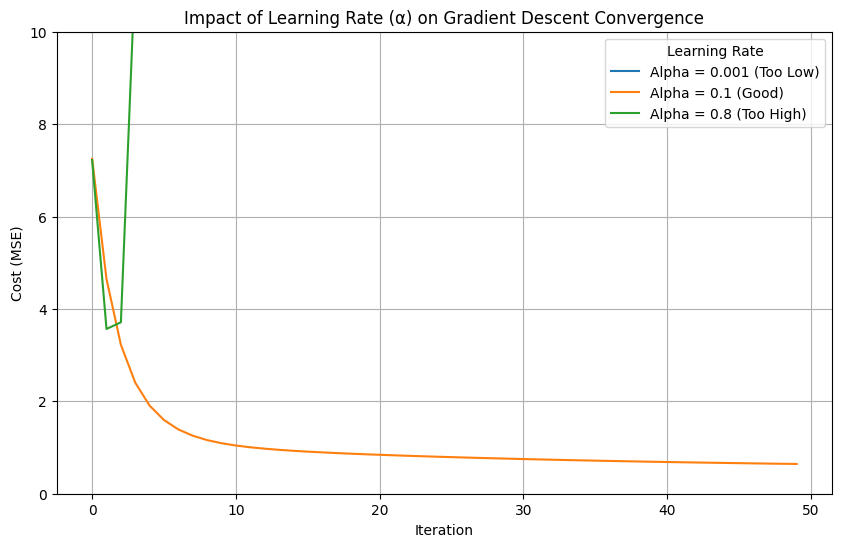

In [7]:
# Run experiments with fewer iterations for plotting
n_iter_plot = 50  # Use fewer iterations for clearer visualization

# Test three different learning rates to demonstrate convergence behavior
cost_alpha_low = run_gd(X_b, y, n, alpha=0.001, n_iterations=n_iter_plot)
# α=0.001: Too small - converges very slowly (tiny steps)

cost_alpha_good = run_gd(X_b, y, n, alpha=0.1, n_iterations=n_iter_plot)
# α=0.1: Good - converges quickly and smoothly (appropriate step size)

cost_alpha_high = run_gd(X_b, y, n, alpha=0.8, n_iterations=n_iter_plot)
# α=0.8: Too large - diverges (overshoots minimum, cost explodes)

# Plot the results to visualize convergence behavior using Seaborn OOP approach
fig, ax = plt.subplots(figsize=(10, 6))

# Create a DataFrame for plotting
iterations = range(n_iter_plot)
data = pd.DataFrame({
	"Iteration": list(iterations) * 3,
	"Cost": cost_alpha_low + cost_alpha_good + cost_alpha_high,
	"Learning Rate": ["Alpha = 0.001 (Too Low)"] * n_iter_plot
	+ ["Alpha = 0.1 (Good)"] * n_iter_plot
	+ ["Alpha = 0.8 (Too High)"] * n_iter_plot,
})

# Create the plot using Seaborn's object-oriented interface
sns.lineplot(data=data, x="Iteration", y="Cost", hue="Learning Rate", ax=ax)

ax.set_title("Impact of Learning Rate (α) on Gradient Descent Convergence")
ax.set_xlabel("Iteration")
ax.set_ylabel("Cost (MSE)")
ax.set_ylim(0, 10)  # Cap y-axis for detail (high α would otherwise explode)
ax.grid(True)
plt.show()

When you run this, you will see:

  * **Blue Line (Too Low):** The cost (MSE) starts to go down, but very, very slowly.
  * **Green Line (Good):** The cost (MSE) drops very quickly and then flattens out, converging on the minimum.
  * **Orange Line (Too High):** The cost (MSE) immediately explodes upwards. This is **divergence**.

This plot is the *visual proof* of why `alpha` is a critical hyperparameter that must be tuned. This entire "from scratch" process gives us a deep, intuitive feel for what the computer is doing when we later just call `model.fit()`.

### Module 3, Phase 3: Applied Practicum - Building Linear Regression

#### Dataset: The Ames Housing Dataset

For this practicum, we will use a subset of the Ames Housing dataset. This is a popular, modern replacement for the old Boston dataset, used to predict the sale price of homes in Ames, Iowa, based on a large number of features.

To make the "from scratch" calculations manageable (especially the matrix inversion for the Normal Equation), we will select just a few key numerical features. This focuses the exercise on the *implementation* of the algorithms, not on advanced feature engineering (which comes later).

#### Starter Code (Minimal Loader)

Here is the code to load the data, select our features, perform a minimal cleaning (just for this practicum), and split the data. You will use the resulting `X_train`, `X_test`, `y_train`, and `y_test` arrays for all tasks.

In [8]:
from sklearn.datasets import fetch_openml
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

housing = fetch_openml(name="house_prices", as_frame=True, parser="auto")
X = housing.data
y = housing.target

features_to_use = ["GrLivArea", "BedroomAbvGr", "FullBath", "LotArea"]
target_name = "SalePrice"

# Handle potential discrepancies in column names if using fallback
if "SalePrice" not in y.name:
	features_to_use = ["MedInc", "AveRooms", "AveBedrms", "Population"]
	target_name = "MedHouseVal"
	X = X[features_to_use]
	y = y
else:
	X = X[features_to_use]
	y = y

# For this exercise, we'll just drop any rows with missing values
# in our selected subset to keep things simple.
data = X.join(y)
data_clean = data.dropna()

X = data_clean[features_to_use].values
y = data_clean[target_name].values
# We also log-transform the target 'y' (SalePrice)
# This is standard practice for heavily skewed price data
# and makes the linear relationship assumption more reasonable.
y_log = np.log(y)

print(f"Using features: {features_to_use}")
print(f"Using target: {target_name} (log-transformed)")

# Split Data
# We split our cleaned data into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(
	X, y_log, test_size=0.2, random_state=42
)

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")


Using features: ['GrLivArea', 'BedroomAbvGr', 'FullBath', 'LotArea']
Using target: SalePrice (log-transformed)
Training data shape: (1168, 4)
Test data shape: (292, 4)


#### Your Tasks

**Task 1: Solution via Normal Equation (From Scratch)**

1.  Create your "design matrix" `X_train_b` from `X_train` by adding the intercept (bias) column of ones.
2.  Write a Python function `solve_normal_equation(X, y)` that takes your `X_train_b` and `y_train` and returns the $\beta$ (beta) coefficient vector by implementing the Normal Equation: $\hat{\beta} = (X^T X)^{-1} X^T y$.
3.  Use your calculated `beta_hat` vector to make predictions on the *test set* (you will need to add an intercept column to `X_test` as well).
4.  Calculate and print the RMSE and $R^2$ score for your predictions.
5.  **Deliverable:** A code cell with your `solve_normal_equation` function, the code to run it, and the printed RMSE/R² results.

#### Normal Equation
$$\hat{\beta} = (X^T X)^{-1} X^T y$$


- $X^T X$: Creates a square matrix of feature covariances
- $(X^T X)^{-1}$: Inverts this matrix (solving step)
- $X^T y$: Computes covariances between features and target
- Multiplying gives the coefficients that minimize prediction error


In [9]:
def solve_normal_equation(X: np.ndarray, y: np.ndarray) -> np.ndarray:
	"""
	Solve linear regression using the Normal Equation method.

	The Normal Equation provides an analytical solution to linear regression
	by finding the coefficients that minimize the sum of squared residuals.

	Mathematical formula: β̂ = (XᵀX)⁻¹Xᵀy

	Parameters
	----------
	X : numpy.ndarray
		Feature matrix with shape (n_samples, n_features) WITHOUT intercept column.
		The function will add the intercept column automatically.
	y : numpy.ndarray
		Target vector with shape (n_samples,)

	Returns
	-------
	beta_hat : numpy.ndarray
		Coefficient vector with shape (n_features+1,) containing intercept and feature coefficients.
		beta_hat[0] is the intercept, beta_hat[1:] are feature coefficients.

	Raises
	------
	LinAlgError
		If the matrix XᵀX is singular and cannot be inverted (indicating perfect multicollinearity).

	Notes
	-----
	- This method is computationally efficient for small to medium-sized datasets
	- Requires matrix inversion which can be expensive for large feature sets (O(p³))
	- Fails if features are perfectly multicollinear (XᵀX is singular)
	- No feature scaling required as this is an analytical solution

	Examples
	--------
	>>> beta = solve_normal_equation(X_train, y_train)
	>>> print(f"Intercept: {beta[0]:.4f}")
	>>> print(f"Coefficients: {beta[1:]}")
	"""
	# Add intercept column (column of ones) to create design matrix
	X_b = np.c_[np.ones((X.shape[0], 1)), X]

	# Compute XᵀX - covariance matrix of features
	XTX = np.dot(X_b.T, X_b)

	# Compute inverse of XᵀX - solving step equivalent to division in linear algebra
	XTX_inv = np.linalg.inv(XTX)

	# Compute Xᵀy - covariance between features and target
	XTy = np.dot(X_b.T, y)

	# Compute optimal coefficients β̂ = (XᵀX)⁻¹Xᵀy
	beta_hat = np.dot(XTX_inv, XTy)

	return beta_hat

In [10]:
# Step 1: Solve for beta using Normal Equation (pass original X_train)
beta_hat_ne = solve_normal_equation(X_train, y_train)

# Step 2: Create design matrix for test set
X_test_b = np.c_[np.ones((X_test.shape[0], 1)), X_test]

# Step 3: Make predictions on test set
y_pred_ne_task = np.dot(X_test_b, beta_hat_ne)

# Step 4: Calculate RMSE and R² score
rmse_ne = np.sqrt(mean_squared_error(y_test, y_pred_ne_task))
r2_ne = r2_score(y_test, y_pred_ne_task)

print(f"Intercept: {beta_hat_ne[0]:.4f}")
print(f"Coefficients: {beta_hat_ne[1:]}")
print(f"Test RMSE: {rmse_ne:.4f}")
print(f"Test R² Score: {r2_ne:.4f}")

Intercept: 11.3069
Coefficients: [ 4.54381003e-04 -1.08357936e-01  1.95446890e-01  3.24950800e-06]
Test RMSE: 0.2674
Test R² Score: 0.6170


**Task 2: Solution via Gradient Descent (From Scratch)**

1.  **Crucial Step:** Standardize your features. Use `sklearn.preprocessing.StandardScaler`. You must `fit_transform` on `X_train` and *only* `transform` on `X_test`.
2.  Create your scaled design matrices `X_train_scaled_b` and `X_test_scaled_b` (which include the intercept column).
3.  Write a Python function `solve_gradient_descent(X, y, learning_rate, n_iterations)` that implements the algorithm.
      * Initialize a random $\beta$ (beta) vector.
      * Loop for `n_iterations`:
          * Calculate predictions $\hat{y} = X\beta$.
          * Calculate the gradient vector: $\nabla J(\beta) = \frac{2}{n} X^T (\hat{y} - y)$.
          * Update $\beta$: $\beta := \beta - (\text{learning\_rate} \times \text{gradient})$.
      * The function should return the final `beta_hat` vector.
4.  Choose a `learning_rate` (e.g., 0.01) and `n_iterations` (e.g., 1000) and run your function to find the $\beta$ vector.
5.  Use your calculated `beta_hat` to make predictions on the *scaled test set* (`X_test_scaled_b`).
6.  Calculate and print the RMSE and $R^2$ score for these predictions.
7.  **Deliverable:** A code cell with your `solve_gradient_descent` function, the code to run it, and the printed RMSE/R² results.

In [11]:
from sklearn.preprocessing import StandardScaler


def solve_gradient_descent(
	X: np.ndarray, y: np.ndarray, learning_rate: float = 0.01, n_iterations: int = 1000
) -> np.ndarray:
	"""
	Solve linear regression using Gradient Descent method.

	Parameters
	----------
	X : numpy.ndarray
		Feature matrix with shape (n_samples, n_features) WITHOUT intercept column
	y : numpy.ndarray
		Target vector with shape (n_samples,)
	learning_rate : float
		Step size for gradient descent (default: 0.01)
	n_iterations : int
		Number of gradient descent iterations (default: 1000)

	Returns
	-------
	beta : numpy.ndarray
		Coefficient vector with shape (n_features+1,) containing intercept and feature coefficients
	"""
	# Scale features for Gradient Descent
	scaler = StandardScaler()
	X_scaled = scaler.fit_transform(X)

	# Add intercept column to scaled features
	X_scaled_b = np.c_[np.ones((X_scaled.shape[0], 1)), X_scaled]

	n = X_scaled_b.shape[0]  # Number of training samples
	p = X_scaled_b.shape[1]  # Number of features including intercept

	# Initialize coefficients randomly
	beta = np.random.randn(p)

	# Gradient Descent loop
	for i in range(n_iterations):
		# Forward pass: Calculate predictions ŷ = Xβ
		y_pred = np.dot(X_scaled_b, beta)

		# Calculate residuals (prediction errors)
		residuals = y_pred - y

		# Calculate gradient vector: ∇J(β) = (2/n) * Xᵀ * residuals
		gradient = (2 / n) * np.dot(X_scaled_b.T, residuals)

		# Update coefficients using gradient descent
		beta = beta - (learning_rate * gradient)

	return beta


In [12]:
from sklearn.preprocessing import StandardScaler

# Step 1: Scale features and add intercept column
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled_b = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]

# Step 2: Solve using Gradient Descent
beta_hat_gd_task = solve_gradient_descent(
	X_train, y_train, learning_rate=0.01, n_iterations=1000
)

# Step 3: Prepare test set (scale using the same scaler and add intercept)
X_test_scaled = scaler.transform(X_test)
X_test_scaled_b = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]

# Step 4: Make predictions on test set
y_pred_gd_task = np.dot(X_test_scaled_b, beta_hat_gd_task)

# Step 5: Calculate RMSE and R² score
rmse_gd = np.sqrt(mean_squared_error(y_test, y_pred_gd_task))
r2_gd = r2_score(y_test, y_pred_gd_task)

print(f"Intercept: {beta_hat_gd_task[0]:.4f}")
print(f"Coefficients: {beta_hat_gd_task[1:]}")
print(f"Test RMSE (Gradient Descent): {rmse_gd:.4f}")
print(f"Test R² Score (Gradient Descent): {r2_gd:.4f}")

Intercept: 12.0307
Coefficients: [ 0.23774639 -0.08701368  0.10715541  0.03504132]
Test RMSE (Gradient Descent): 0.2674
Test R² Score (Gradient Descent): 0.6169


**Task 3: Solution via `scikit-learn` (The Baseline)**

1.  Instantiate `sklearn.linear_model.LinearRegression`.
2.  Fit the model on the *original* (unscaled) `X_train` and `y_train`. (Note: `scikit-learn` handles the intercept automatically).
3.  Make predictions on the *original* (unscaled) `X_test`.
4.  Calculate and print the RMSE and $R^2$ score.
5.  **Deliverable:** A code cell that implements this and prints the results.

**Task 4: Comparison and Interpretation Report**

1.  Look at the RMSE/R² results from all three methods (Normal Eq, Gradient Descent, `scikit-learn`). They should be very similar, if not identical.
2.  Look at the $\beta$ (beta) coefficients from your Normal Equation (Task 1) and from the `scikit-learn` model (Task 3). The `sklearn` coefficients can be accessed via `model.coef_` and `model.intercept_`.
3.  Look at the $\beta$ (beta) coefficients from your Gradient Descent (Task 2).
4.  **Deliverable:** A markdown cell that answers these questions:
      * **Performance:** Did all three methods achieve roughly the same RMSE and $R^2$?
      * **Coefficients (Unscaled):** Do the coefficients from your Normal Equation (Task 1) match the `intercept_` and `coef_` from the `scikit-learn` model (Task 3)?
      * **Coefficients (Scaled):** Why are the coefficients from your Gradient Descent (Task 2) *completely different* from the other two? (Hint: What data did you train it on?) What do these scaled coefficients *mean*?
      * **Conclusion:** Briefly explain why scaling *was not* required for the Normal Equation but *was* mandatory for Gradient Descent to work effectively.